# İlk Tekrarlayan Sinir Ağınız (RNN)

🙌 RNN'lere hoş geldiniz! Önceki derste görseller (uzamsal veri) ile ilgilenmek için CNN'leri kullandıktan sonra, şimdi zamanla ilgili veriler (***zamansal veri***) ile ilgileneceksiniz.

🎯 Bu ısınma challenge'ının hedefleri:

1. Zamansal verinin ne olduğunu anlamak
2. İlk Tekrarlayan Sinir Ağlarınızı oluşturmak



_Not: Google Colab kullanmaya gerek yok ❌_

## (1) 📚 Veri seti

_Uyarı: bu bölümde kendiniz kod yazmanıza gerek yok, dikkatli okuyun ve hücreleri çalıştırın. RNN ve LSTM modellerine odaklanmanızı istiyoruz, Python sorularına değil_ 😉

🔢 Bir şirketteki çalışanlar hakkında bazı verilere erişimimiz olduğunu düşünün.

In [1]:
import numpy as np

X = np.load('X.npy')
y = np.load('y.npy')

In [2]:
X.shape, y.shape

((25000, 10, 3), (25000,))

☝️ Veri seti **25.000 çalışanın istihdam durumunun yıllar içindeki gelişimini** tanımlar: her sekans 10 ardışık yıla karşılık gelir ve her yıl 3 bileşenden oluşan bir iş durumunu açıklar
- maaş,
- sorumluluğundaki kişi sayısı,
- şirketin büyüklüğü.

🕵🏻 Veri setini biraz daha iyi anlamak için ilk çalışanın verilerine bakalım.

In [3]:
import pandas as pd

employee_0 = pd.DataFrame(X[0],
                          columns=['salary',
                                   'responsibility',
                                   'company_size'])
round(employee_0,2)

,salary,responsibility,company_size
0,0.80,10.73,102.0
1,0.50,10.73,102.0
2,0.60,10.73,102.0
3,0.71,10.73,130.0
4,0.94,10.73,130.0
5,1.05,10.73,130.0
6,1.12,32.00,108.0
7,4.87,32.00,108.0
8,4.97,33.00,108.0
9,5.20,39.00,108.0


🎯 Bu challenge'ın amacı, geçmiş gözlemlere dayanarak bu 25.000 çalışanın her biri için 11. yıldaki aylık maaşı tahmin etmektir.

In [4]:
# For example, the first employee earns 6.499 k USD per month
# during the 11th year at the company
y[0]

6.499

📈 Maaşların, sorumluluklarındaki kişi sayısının ve şirket büyüklüğünün yıllar içindeki gelişimini daha iyi anlamanız için aşağıdaki hücreyi çalıştırabilirsiniz. Bu üç değişken arasında görsel olarak bazı korelasyonlar tespit edebiliyor musunuz?

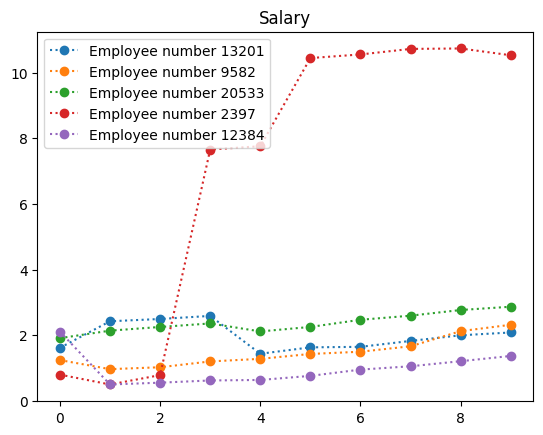

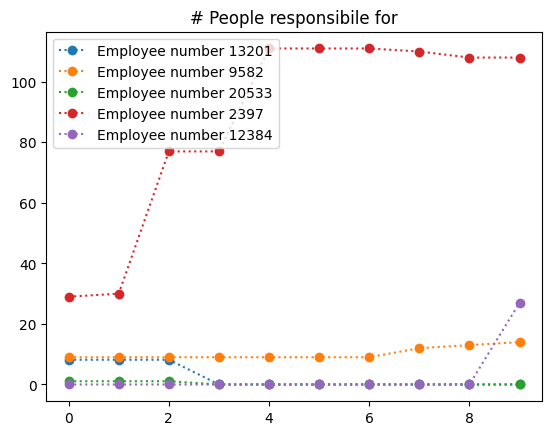

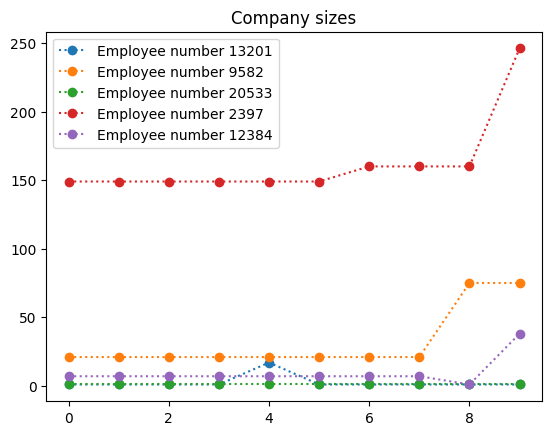

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

number_of_employees = len(X)

### Choosing random employees
##### As the employees are selected randomly, feel free to re-run this cell a few times !

number_of_randomly_selected_employees = 5

random_selection = np.random.randint(0,
                                     number_of_employees,
                                     number_of_randomly_selected_employees)


### Plotting data for the selected employees

plt.title('Salary')
for r in random_selection:
    plt.plot(X[r, :, 0],label=f"Employee number {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

plt.title('# People responsibile for')
for r in random_selection:
    plt.plot(X[r, :, 1],label=f"Employee number {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

plt.title('Company sizes')
for r in random_selection:
    plt.plot(X[r, :, 2],label=f"Employee number {r}",linestyle=":",marker="o")
    plt.legend(loc='upper left')
plt.show()

🕵🏻 **Veri Keşfi** 🕵🏻 Gözlemlerin değişkenliğini daha iyi anlamak için şunların dağılımına bakın:
* 10. yıldaki tüm maaşlar,
* sorumluluğundaki kişiler,
* ve şirket büyüklükleri

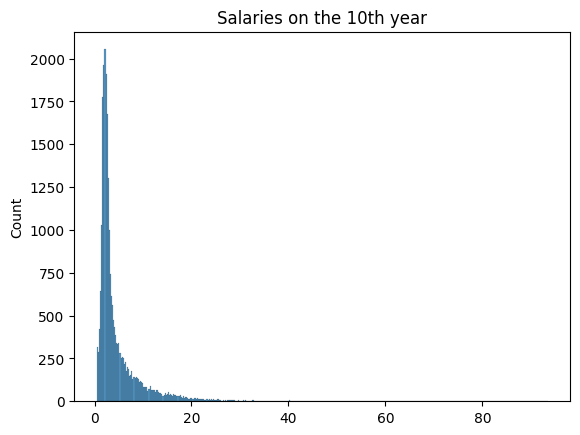

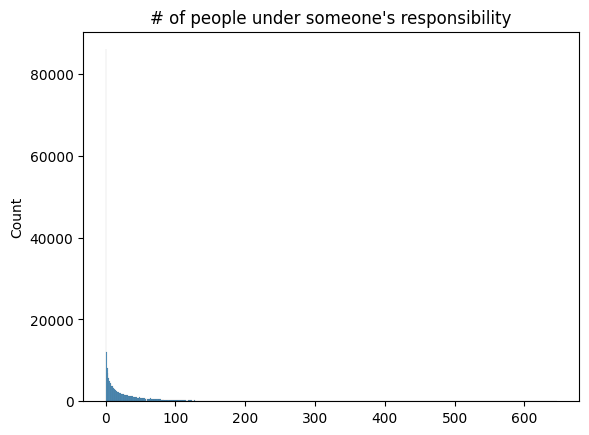

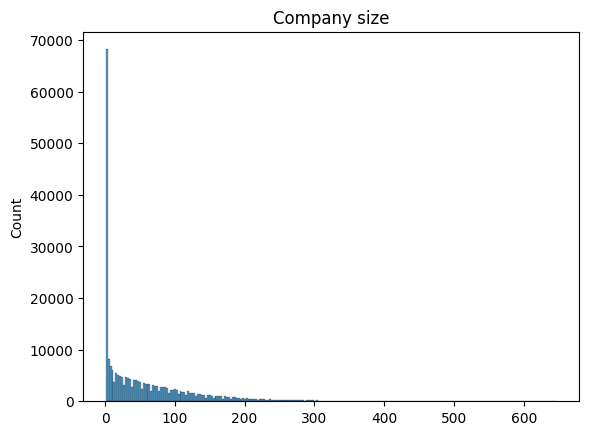

In [6]:
import seaborn as sns

plt.title("Salaries on the 10th year")
sns.histplot(X[:, -1, 0].flatten()) # all the employees, last year, feature #0 = salaries
plt.show()

plt.title("# of people under someone's responsibility")
sns.histplot(X[:, :, 1].flatten()) # all the employees, all the years, feature #1 = responsabilities
plt.show()

plt.title("Company size")
sns.histplot(X[:, :, 2].flatten()) # all the employees, all the years, feature #2 = company size
plt.show()

✂️ **Tutma yöntemi** Veri setini eğitim ve test setine ayıralım (80/20)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Notice that we are train_test_splitting the 25 000 employees!

## (2) 💻 Basit bir RNN

🤗 Artık bu şirketin veri setiyle tanıştığınıza göre, ilk Tekrarlayan Sinir Ağınızı oluşturacaksınız. Basit bir mimariyle başlayalım.

❓ **Soru** ❓ Şunları içeren bir model yazın:
- Eğitim setine uyarlanmış bir ***Normalization*** katmanı
- 20 *ünite* içeren bir ***SimpleRNN*** katmanı (Tekrarlayan Katman için aktivasyon fonksiyonu olarak `tanh`'ın daha uygun olduğunu unutmayın)
- 10 nöronlu bir ***Dense*** katmanı
- Görevinize özel bir ***Dense*** katmanı (= maaş ***tahmini*** yapmak için)

👩🏻‍🏫 Unutmayın: İlk katmandan önce `keras.Input` eklemeyi unutmayın.

In [8]:
from keras import Sequential, Input
from keras.layers import Dense, SimpleRNN, Flatten, Normalization

2026-09-20 16:30:42.046233: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-20 16:30:42.738108: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-20 16:30:43.889205: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-20 16:30:44.843376: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-20 16:30:44.852481: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-20 16:30:46.363477: I tensorflow/core/platform/cpu_feature_guard.cc:

In [9]:
# Normalization Katmanını X_train'e uyarlama
normalizer = Normalization()
normalizer.adapt(X_train)

# RNN mimarisini oluşturma
#model = Sequential()
#model.add(Input(shape=X_train.shape[1:]))
#model.add(normalizer)
#model.add(SimpleRNN(units=20, activation='tanh'))
#model.add(Dense(10, activation='relu'))
#model.add(Dense(1, activation='linear'))

model = Sequential([
    Input(shape=(10, 3)),
    normalizer,
    SimpleRNN(units=20, activation='tanh'),
    Dense(10, activation='relu'),
    Dense(1, activation='linear')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 10, 3)          │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 20)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 708 (2.77 KB)

 Trainable params: 701 (2.74 KB)

 Non-trainable params: 7 (32.00 B)

❓ **Soru**: RNN'inizde kaç tane eğitilebilir parametre var ❓

❓ **Soru** ❓ Parametre sayısını elle yeniden hesaplamaya çalışın.


SimpleRNN için formül: 
Parametre = (input features x units) + (units x units) + units

input features: 3
RNN Units: 20

Trainable parameters:
    SimpleRNN:  (3*20) + (20*20) + 20 = 480
    Dense(10):  (20*10) + 10 = 210
    Dense(1):   (10*1) + 1 = 11
    Total trainable parameters = 480 + 210 + 11 = 701
    

<details>
    <summary><i>Cevap</i></summary>


- <u> Normalizasyon Katmanı</u>: 
    - Bu katman normalize edilecek $\color{red}{n_x = 3} $ özelliğe (maaş, sorumluluk, şirket büyüklüğü) sahiptir. Her biri için <font color=blue>_ortalama_</font> ve <font color=blue>_standart_sapma_</font> hesaplanması gerekir. Yani $\color{red}{n_x = 3} \times \color{blue}{2} = 6$ eğitilemez parametremiz vardır. 7. parametre başlangıçta 0'a ayarlanmış bir bias'tır.

- <u> Tekrarlayan Katman</u>: 
    - Eğer $\color{green}{n_h = 20} $ RNN ünitesi $\color{red}{n_x = 3} $ özelliğe paralel uygulanırsa, Tekrarlayan Katman $\color{green}{n_h}(\color{green}{n_h} + \color{red}{n_x} + 1) = \color{green}{20} \times (\color{green}{20}+\color{red}{3}+1) = \color{green}{20} \times 24 = 480$ eğitilebilir parametreye sahiptir.
    - Bu sayının her sekansın uzunluğundan (burada 10 gün) *bağımsız* olduğuna dikkat edin
    
- <u> Yoğun Katman</u>: 
    - $\color{green}{n_h = 20} $ RNN ünitesi ve $1$ bias ile başlayarak, 10 nöron kullanarak, Yoğun Katman $ (\color{green}{20}+1) \times 10 = 21 \times 10 = 210$ parametreye sahiptir
    
- <u> Tahmin Yoğun Katmanı</u>: 
    - $10$ nöron ve $1$ bias ile başlayarak, 11. maaşı tahmin etmek için 1 nöron kullanarak, Tahmin Yoğun Katmanı $ (10+1) \times 1 = 11 \times 1 = 11$ parametreye sahiptir
    
</details>    

❓ **Soru** ❓ Modelinizi derleyin. RNN için ***rmsprop*** optimizer'ını (*adam* yerine) kullanmanızı öneriyoruz.

In [10]:
def compile_model(model):
    model.compile(loss='mse',
                  optimizer='rmsprop',
                  metrics=['mae'])
    return model

model = compile_model(model)

❓ **Sorular** ❓ 

* Modelinizi eğitim veri setinizde eğitin:
    * %20'lik bir Doğrulama Bölümü kullanın
    * ve sabır $= 5 $ olan bir Erken Durdurma Kriteri kullanın
* Test setindeki performansınızı değerlendirin

In [11]:
%%time

from keras.callbacks import EarlyStopping

#es = EarlyStopping(patience=5, restore_best_weights=True)

#history = model.fit(X_train, y_train,
#                    validation_split=0.2,
#                    batch_size=32,
#                    epochs=100,
#                    callbacks=[es],
#                    verbose=1)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)


Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - loss: 20.2949 - mae: 1.8459 - val_loss: 3.5832 - val_mae: 0.5967
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 3.2011 - mae: 0.5042 - val_loss: 1.3059 - val_mae: 0.4302
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 1.6236 - mae: 0.4028 - val_loss: 0.9606 - val_mae: 0.3768
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 1.2466 - mae: 0.3758 - val_loss: 0.8373 - val_mae: 0.3144
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - loss: 1.0566 - mae: 0.3664 - val_loss: 0.9072 - val_mae: 0.4806
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.9542 - mae: 0.3613 - val_loss: 0.7504 - val_mae: 0.2921
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.8631 - mae: 0.3549 - val_loss: 0.7278 - val_mae: 0.2844
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.8125 - mae: 0.3489 - val_loss: 0.7281 - val_mae: 0.2975
Epoch 9/100
500/500 ━━━━━━━━━━━

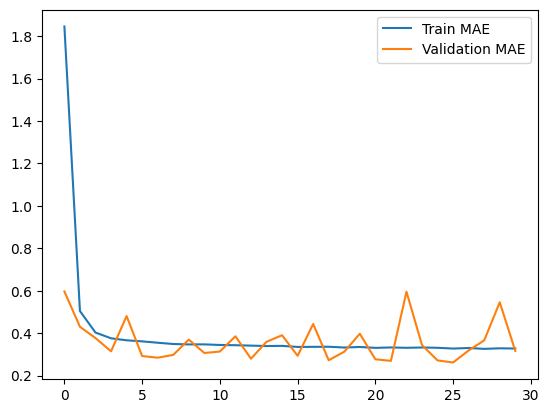

In [12]:
plt.plot(history.history["mae"], label = "Train MAE")
plt.plot(history.history["val_mae"], label = "Validation MAE")
plt.legend()

In [13]:
model_mae = model.evaluate(X_test, y_test, verbose=0)

print(f'Model Ortalama Mutlak Hatası {model_mae[1]:.4f}')

Model Ortalama Mutlak Hatası 0.2555


## (3) 💻 Temel karşılaştırma

> ❗️ **Önemli hatırlatma** ❗️ 
>  
> ***Derin Öğrenme modellerinizi ve daha genel olarak herhangi bir Makine Öğrenmesi modelini her zaman bir temel modelle karşılaştırmayı unutmayın.***

🧑🏻‍🏫 Amacımızın çalışanların 11. yıl için maaşını tahmin etmek olduğunu unutmayın. Bu bir ***Regresyon görevidir***. Hangi temel modeli oluşturabiliriz?
1. Geleneksel regresyon modeli durumunda, `y_test` için temel tahmin **`y_train`'in ortalamasını tahmin etmektir**... ancak bu seçenek zamanla ilgili seriler için alakasız olabilir. Teorik olarak, birinin maaşının yıllar içinde artması gerekir!
2. Regresyon görevi için alternatif temel tahmin **son görülen değeri tahmin etmektir**

❓ **Sorular** ❓ 
* 10. ve 11. yıl arasında maaşın sabit kaldığını tahmin eden temel modelin Ortalama Mutlak Hatasını hesaplayın
* Bu temel modeli RNN'inizle karşılaştırın

In [14]:
# Sonraki maaşı tahmin etmek için X'teki son maaşı kullanma
y_test_baseline = X_test[:, -1, 0]
mae_baseline = np.mean(np.abs(y_test - y_test_baseline))

print(f'Temel Model MAE = {mae_baseline:.3f}')
print("karşısında")
print(f'RNN MAE = {model_mae[1]:.3f}')

Temel Model MAE = 0.562
karşısında
RNN MAE = 0.256


👉 Bu soruda takılırsanız, `(4) LSTM`'i deneyin ve sonra buraya geri dönün.

🧑🏻‍🏫 Gerekirse TA'ya sorun. Cevaba sadece bu soruları başarısızlıkla cevaplamaya çalıştıktan sonra bakın.

<details>
    <summary><i>Cevap</i></summary>


```python
# Bir sonraki maaşı tahmin etmek için X'teki son maaşı kullanma
y_test_baseline = X_test[:, -1, 0] 
mae_baseline = np.mean(np.abs(y_test - y_test_baseline))   
```
    
</details>    

😁 RNN'inizin temel modelden biraz daha iyi performans gösterdiğini fark etmelisiniz.

## (4) 💻 LSTM: Uzun-Kısa Süreli Bellek

❓ **Sorular** ❓ 

* Aynı modeli yazın, ancak `SimpleRNN` katmanı yerine `LSTM` katmanı ile
* Test setindeki performansınızı değerlendirin

In [15]:
%%time

from keras.layers import LSTM
from keras.callbacks import EarlyStopping

model_LSTM = Sequential()
model_LSTM.add(normalizer)
model_LSTM.add(LSTM(units=20, activation='tanh'))
model_LSTM.add(Dense(10, activation='relu'))
model_LSTM.add(Dense(1, activation='linear'))

model_LSTM = compile_model(model_LSTM)

es = EarlyStopping(patience=5, restore_best_weights=True)

history_LSTM = model_LSTM.fit(X_train, y_train,
                              validation_split=0.2,
                              batch_size=32,
                              epochs=100,
                              callbacks=[es],verbose=1)

model_LSTM.summary()

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - loss: 18.1208 - mae: 1.9342 - val_loss: 3.6194 - val_mae: 0.8093
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - loss: 2.9101 - mae: 0.5774 - val_loss: 1.0609 - val_mae: 0.3860
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - loss: 1.3996 - mae: 0.3707 - val_loss: 0.8107 - val_mae: 0.3455
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - loss: 1.0219 - mae: 0.3348 - val_loss: 0.7111 - val_mae: 0.2855
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - loss: 0.8858 - mae: 0.3206 - val_loss: 0.6932 - val_mae: 0.3075
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.8032 - mae: 0.3165 - val_loss: 0.6893 - val_mae: 0.3038
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 0.7440 - mae: 0.3092 - val_loss: 0.8574 - val_mae: 0.4641
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - loss: 0.7175 - mae: 0.3073 - val_loss: 0.6938 - val_mae: 0.3402
Epoch 9/100
500/500 ━━━━━━━━━━━

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (32, 10, 3)            │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (32, 20)               │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 10)               │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 1)                │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,291 (16.77 KB)

 Trainable params: 2,141 (8.36 KB)

 Non-trainable params: 7 (32.00 B)

 Optimizer params: 2,143 (8.38 KB)

CPU times: user 1min 27s, sys: 1min 24s, total: 2min 51s
Wall time: 9min 55s


LSTM tek bir basit recurrent hesap yerine temelde 4 ayrı hesaplama bloğu taşır; forget gate, input gate, output gate ve candidate cell state. Dolayısıyla parametre formülü:

4 x units x (units + input_features + 1)

yani bizde:

4 x 20 x (20 + 3 + 1) = 4 x 20 x 24 = 1920

yani

SimpleRNN(20)   > 480 parametre
LSTM(20)        > 1920 parametre

LSTM, RNN'in otomatik olarak daha iyi versiyonu değil, daha karmaşık ve daha fazla parametreli bir recurrent mimari. Uzun dönem bağımlılıkları daha iyi öğrenebilmesi karşılığında bunun bir hesaplama maliyeti var.

LSTM modelinin gerçek ağırlıkları;

Normalization       7
LSTM                1920
Dense               210
Dense               11
_______

Model ağırlıkları   2148

Bunların içinde eğitilebilir olanlar : 1920 + 210 + 11 = 2141
Normalizasyon'un 7 parametresi non-trainable olduğu için

Trainable params:       2141
Non-trainable params:   7

Ekrandaki total params = 4291 neden 2148 değil? Çünkü Keras burada optimizer'ın eğitim sırasında tuttuğu 2143 optimizer state değişkenini de toplam sayıya dahil etmiş.

LSTM yaklaşık 10 dk., SimpleRNN yaklaşık 6dk. sürdü. Bu, LSTM'in dört ayrı hesaplama mekanizması kullanmasının doğal sonucu. 

Model Ortalama Mutlak Hatası (MAE): 0.26930955052375793


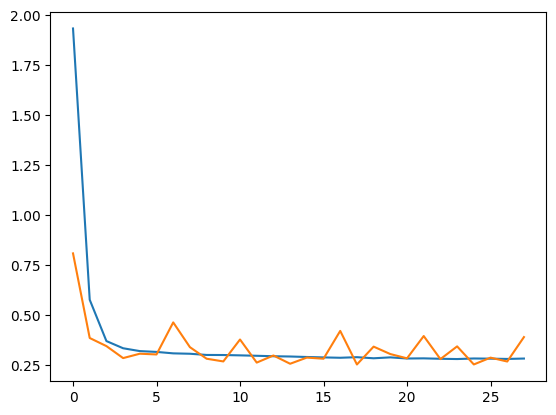

In [17]:
plt.plot(history_LSTM.history["mae"])
plt.plot(history_LSTM.history["val_mae"])
print("Model Ortalama Mutlak Hatası (MAE):", model_LSTM.evaluate(X_test, y_test, verbose=0)[1])

Bu çalışada SimpleRNN, LSTM'den biraz daha düşük test hatası üretti. Bu, LSTM'in kötü anlamnıa gelmez. LSTM'in avantajı özellikle uzun dönem bağımlılıklarda ortaya çıkar. Burada sequence yanlnızca 10timestep.

💪 LSTM, daha düşük MAE ile SimpleRNN'den biraz daha iyi performans göstermelidir.

🏁 Tebrikler! Sıralı veriler üzerinde RNN eğitmeyi öğrendiniz.
 

💾 Notebook'unuzu git add/commit/push yapmayı unutmayın...

🚀 ... ve sonraki challenge'a geçin!

---

<u>Not</u>: Üzerinde çalıştığınız sekanslar tamamen sahte. Benzer verileri eğitmeniz ve üretmeniz gerektiğinde, böyle bir veri setini simüle etmek için kullanılan fonksiyonları aşağıda bulabilirsiniz.

## 🛠 (Yardımcı Araçlar)

In [ ]:
def create_sequences(number):
    X, y = [], []

    for i in range(number):
        x_i, y_i = create_individual_sequence(10)
        X.append(x_i)
        y.append(y_i)

    return np.array(X), np.array(y)

def create_individual_sequence(length):
    company_sizes = []
    nb_persons = []
    salaries = []


    # Education level
    educ_level = [max(0, int(np.random.normal(10, 2)))]*length

    # Company size
    current_size = int(1 + np.random.beta(.4, 4)*500)
    for i in range(length):
        if not np.random.randint(4): # Change 1 out of 3 possibilities
            current_size = int(max(1, np.random.normal(current_size, 50)))
        company_sizes.append(current_size)

    # Number of persons
    nb_iter = np.random.beta(.15, 4)*300
    for i in range(length):
        if not np.random.randint(2): # Change 1 out of 2 possibilities
            R_1 = np.random.beta(0.5, 8)*3
            nb_iter = nb_iter + max(-2, R_1*company_sizes[i] + np.random.randint(-2, 2))
            nb_iter = max(0, nb_iter)
            nb_iter = int(min(company_sizes[i]-1, nb_iter))
        nb_persons.append(nb_iter)


    # Salary
    salary_iter = max(800, int(np.random.normal(1200, 300)+ 0.05*company_sizes[0] +  np.random.normal(40, 400)))
    salaries.append(salary_iter)
    for i in range(1, length + 1):
        R_1 = np.random.normal(100, 50)
        change_person = nb_persons[i-1] - nb_persons[i-2]
        change_company = max(0, company_sizes[i-1] - company_sizes[i-2])
        salary_iter = salary_iter + 0.05*change_company + change_person*R_1 + np.random.normal(100, 50)
        salary_iter = max(int(salary_iter), 500)

        salaries.append(salary_iter)

    y = salaries[-1]/1000
    salaries = [_/1000 for _ in salaries[:-1]]

    return np.array([salaries, nb_persons, company_sizes]).T, y

In [ ]:
#X, y = create_sequences(25000)

#np.save('X', X.astype(np.float32))
#np.save('y', y)